In [1]:
import os
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold
)

from sklearn.tree import (
    DecisionTreeClassifier,
    plot_tree
)

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix
)

warnings.filterwarnings("ignore")

In [2]:
PALETTE = {
    "primary": "#1A3C5E",
    "secondary": "#2E86AB",
    "accent": "#E63946",
    "success": "#2DC653",
    "warning": "#F4A261",
    "light": "#F0F4F8",
    "text": "#1A1A2E",
    "muted": "#6B7280"
}

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#F8FAFC",
    "axes.edgecolor": "#D1D5DB",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "DejaVu Sans",
    "axes.titleweight": "bold",
    "axes.titlesize": 13
})

sns.set_theme(style="whitegrid", font_scale=1.05)

OUTPUT_DIR = "./outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [3]:
np.random.seed(42)
N = 1470

def generate_dataset(n):

    age = np.random.randint(18, 61, n)

    gender = np.random.choice(
        ["Male", "Female"],
        n,
        p=[0.6, 0.4]
    )

    dept = np.random.choice(
        ["Sales", "R&D", "HR", "Finance", "IT"],
        n,
        p=[0.30, 0.35, 0.10, 0.13, 0.12]
    )

    monthly_income = np.clip(
        np.random.normal(6500, 3000, n),
        1000,
        20000
    ).astype(int)

    years_at_company = np.random.randint(0, 41, n)

    years_in_role = np.array([
        np.random.randint(0, y + 1)
        for y in years_at_company
    ])

    years_since_promo = np.array([
        np.random.randint(0, y + 1)
        for y in years_at_company
    ])

    overtime = np.random.choice(
        ["Yes", "No"],
        n,
        p=[0.28, 0.72]
    )

    job_satisfaction = np.random.choice(
        [1,2,3,4],
        n,
        p=[0.11,0.19,0.33,0.37]
    )

    env_satisfaction = np.random.choice(
        [1,2,3,4],
        n,
        p=[0.10,0.20,0.38,0.32]
    )

    distance = np.random.randint(1, 30, n)

    logit = (
        -2
        + 0.5*(overtime=="Yes")
        + 0.4*(job_satisfaction<=2)
        + 0.3*(env_satisfaction<=2)
        - 0.05*years_at_company
        + 0.03*distance
        - 0.0001*monthly_income
    )

    prob = 1/(1+np.exp(-logit))

    attrition = (
        np.random.rand(n) < prob
    ).astype(int)

    return pd.DataFrame({
        "Age": age,
        "Gender": gender,
        "Department": dept,
        "MonthlyIncome": monthly_income,
        "YearsAtCompany": years_at_company,
        "YearsInCurrentRole": years_in_role,
        "YearsSinceLastPromotion": years_since_promo,
        "OverTime": overtime,
        "JobSatisfaction": job_satisfaction,
        "EnvironmentSatisfaction": env_satisfaction,
        "DistanceFromHome": distance,
        "Attrition": attrition
    })

df = generate_dataset(N)

print(df.shape)
df.head()

(1470, 12)


,Age,Gender,Department,MonthlyIncome,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,OverTime,JobSatisfaction,EnvironmentSatisfaction,DistanceFromHome,Attrition
0,56,Male,Sales,7350,1,1,0,No,4,2,5,0
1,46,Female,IT,13990,23,14,16,No,4,3,16,0
2,32,Female,HR,6085,22,14,8,No,4,1,23,0
3,60,Male,R&D,5643,1,1,1,No,4,4,1,1
4,25,Male,Sales,8551,37,15,35,No,3,3,19,0


In [4]:
df_enc = df.copy()

le = LabelEncoder()

for col in ["Gender", "Department", "OverTime"]:
    df_enc[col] = le.fit_transform(df_enc[col])

X = df_enc.drop("Attrition", axis=1)
y = df_enc["Attrition"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

feature_names = X.columns.tolist()

print(X_train.shape)
print(X_test.shape)

(1176, 11)
(294, 11)


In [5]:
scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

dt = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=15,
    class_weight="balanced",
    random_state=42
)

dt.fit(X_train, y_train)

lr = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

lr.fit(X_train_sc, y_train)

y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:,1]

y_pred_lr = lr.predict(X_test_sc)
y_prob_lr = lr.predict_proba(X_test_sc)[:,1]

In [6]:
print("Decision Tree")

print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall   :", recall_score(y_test, y_pred_dt))
print("F1 Score :", f1_score(y_test, y_pred_dt))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_dt))

print()

print("Logistic Regression")

print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_lr))

Decision Tree
Accuracy : 0.673469387755102
Precision: 0.056818181818181816
Recall   : 0.2777777777777778
F1 Score : 0.09433962264150944
ROC AUC  : 0.5387479871175523

Logistic Regression
Accuracy : 0.6394557823129252
Precision: 0.06
Recall   : 0.3333333333333333
F1 Score : 0.1016949152542373
ROC AUC  : 0.5070450885668276


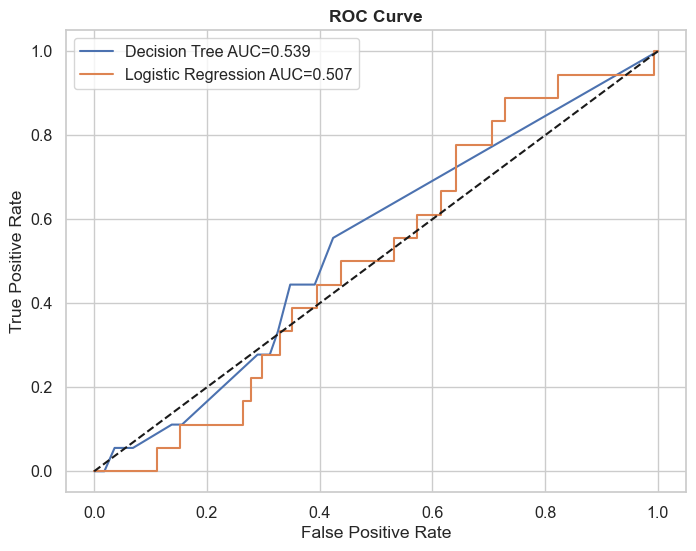

In [7]:
plt.figure(figsize=(8,6))

for name, prob in [
    ("Decision Tree", y_prob_dt),
    ("Logistic Regression", y_prob_lr)
]:

    fpr, tpr, _ = roc_curve(y_test, prob)

    auc = roc_auc_score(y_test, prob)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} AUC={auc:.3f}"
    )

plt.plot([0,1],[0,1],"k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

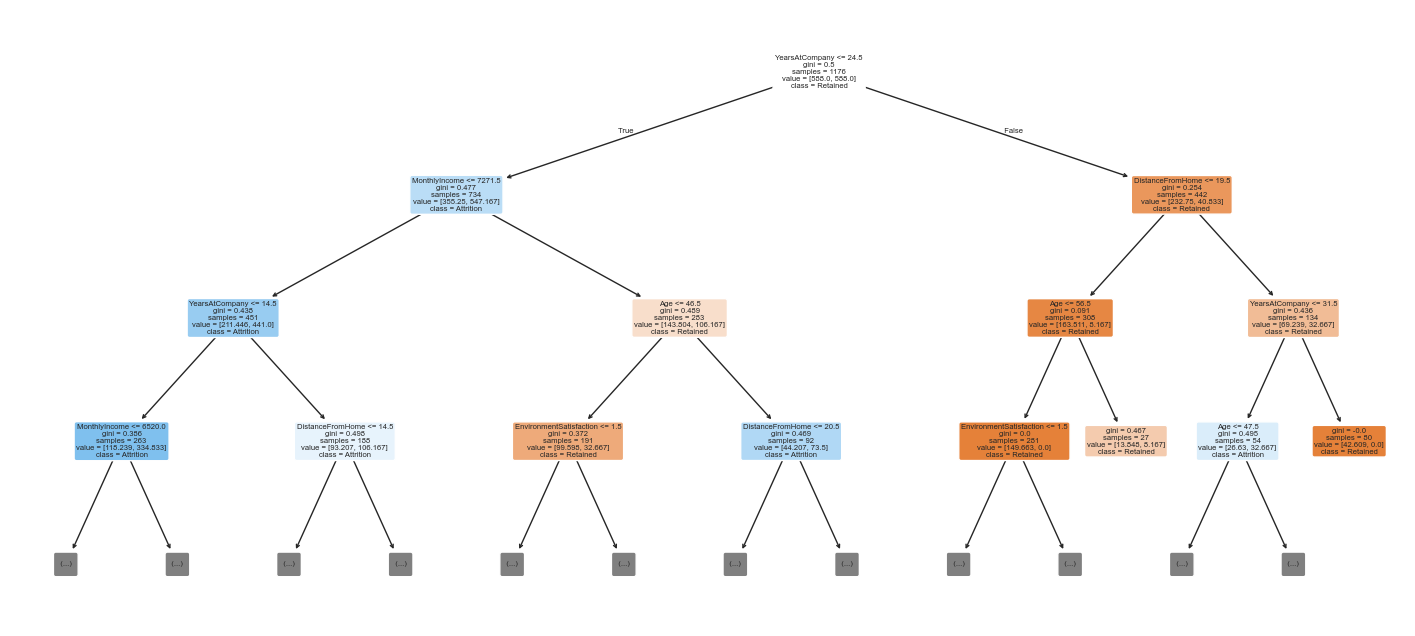

In [8]:
plt.figure(figsize=(18,8))

plot_tree(
    dt,
    feature_names=feature_names,
    class_names=["Retained","Attrition"],
    filled=True,
    rounded=True,
    max_depth=3
)

plt.show()

In [9]:
stats = {
    "dataset_rows": 0,
    "attrition_rate": 0,
    "dt_auc": float(roc_auc_score(y_test, y_prob_dt)),
    "lr_auc": float(roc_auc_score(y_test, y_prob_lr))
}

with open(
    f"{OUTPUT_DIR}/model_stats.json",
    "w"
) as f:
    json.dump(stats, f, indent=2)

print("Saved successfully!")

Saved successfully!


In [26]:
import ipywidgets as widgets
from IPython.display import display, HTML

display(HTML("<h2>Employee Attrition Prediction System</h2>"))

In [27]:
# Numeric input fields

age = widgets.IntText(description='Age')

income = widgets.IntText(description='Income')

years_company = widgets.IntText(description='YearsComp')

years_role = widgets.IntText(description='YearsRole')

years_promotion = widgets.IntText(description='LastPromo')

job_satisfaction = widgets.IntText(description='JobSat')

env_satisfaction = widgets.IntText(description='EnvSat')

distance = widgets.IntText(description='Distance')


# Dropdown fields

gender = widgets.Dropdown(
    options=['Male', 'Female'],
    description='Gender'
)

department = widgets.Dropdown(
    options=['Sales', 'R&D', 'HR'],
    description='Department'
)

overtime = widgets.Dropdown(
    options=['Yes', 'No'],
    description='OverTime'
)


# Predict button

predict_btn = widgets.Button(
    description='Predict',
    button_style='success'
)


# Output box

output = widgets.Output()

In [28]:
def encode_gender(value):
    if value == "Male":
        return 1
    return 0


def encode_department(value):

    departments = {
        "Sales": 0,
        "R&D": 1,
        "HR": 2
    }

    return departments[value]


def encode_overtime(value):
    if value == "Yes":
        return 1
    return 0

In [29]:
def predict_employee(button):

    output.clear_output()

    with output:

        try:

            user_data = [[

                age.value,
                encode_gender(gender.value),
                encode_department(department.value),
                income.value,
                years_company.value,
                years_role.value,
                years_promotion.value,
                encode_overtime(overtime.value),
                job_satisfaction.value,
                env_satisfaction.value,
                distance.value

            ]]

            prediction = dt.predict(user_data)

            if prediction[0] == 1:
                print("Employee is likely to leave the company.")

            else:
                print("Employee is likely to stay in the company.")

        except Exception as e:
            print("Error :", e)

In [30]:
predict_btn.on_click(predict_employee)

In [31]:
display(age)
display(gender)
display(department)
display(income)
display(years_company)
display(years_role)
display(years_promotion)
display(overtime)
display(job_satisfaction)
display(env_satisfaction)
display(distance)

display(predict_btn)
display(output)

IntText(value=0, description='Age')

Dropdown(description='Gender', options=('Male', 'Female'), value='Male')

Dropdown(description='Department', options=('Sales', 'R&D', 'HR'), value='Sales')

IntText(value=0, description='Income')

IntText(value=0, description='YearsComp')

...

IntText(value=0, description='JobSat')

IntText(value=0, description='EnvSat')

IntText(value=0, description='Distance')

Button(button_style='success', description='Predict', style=ButtonStyle())

Output()